In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [111]:
cust_ch_df = pd.read_csv(r"C:\Users\sudip\Downloads\DataSets\CSV\WA_Fn-UseC_-Telco-Customer-Churn.csv")
cust_ch_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [112]:
cust_ch_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [113]:
for i in cust_ch_df.columns:
    print(i, ':', cust_ch_df[i].unique(), '\n')

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 

gender : ['Female' 'Male'] 

SeniorCitizen : [0 1] 

Partner : ['Yes' 'No'] 

Dependents : ['No' 'Yes'] 

tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] 

PhoneService : ['No' 'Yes'] 

MultipleLines : ['No phone service' 'No' 'Yes'] 

InternetService : ['DSL' 'Fiber optic' 'No'] 

OnlineSecurity : ['No' 'Yes' 'No internet service'] 

OnlineBackup : ['Yes' 'No' 'No internet service'] 

DeviceProtection : ['No' 'Yes' 'No internet service'] 

TechSupport : ['No' 'Yes' 'No internet service'] 

StreamingTV : ['No' 'Yes' 'No internet service'] 

StreamingMovies : ['No' 'Yes' 'No internet service'] 

Contract : ['Month-to-month' 'One year' 'Two year'] 

PaperlessBilling : ['Yes' 'No'] 

PaymentMethod : ['Electro

In [114]:
cust_ch_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

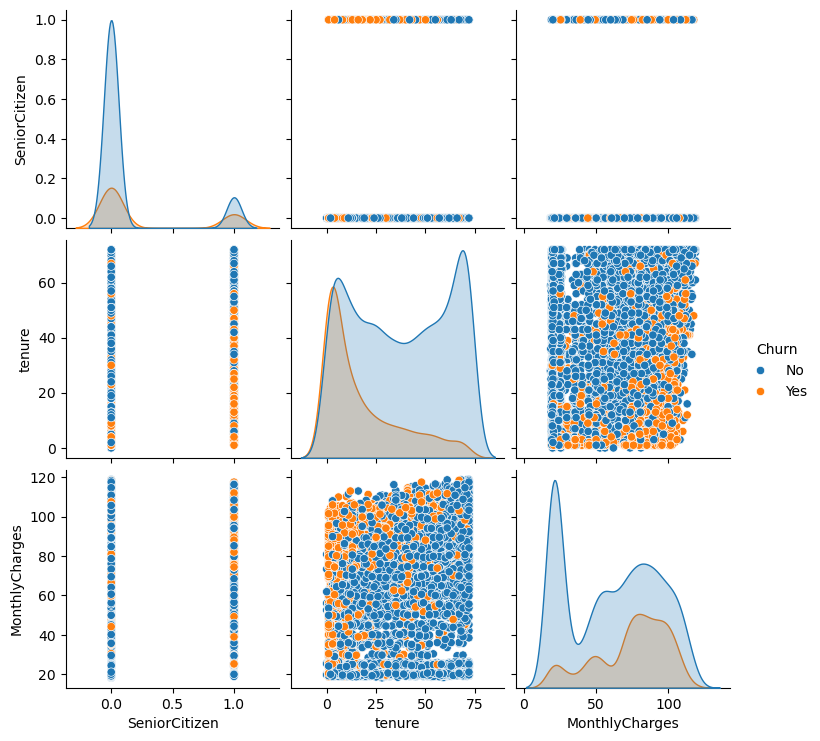

In [100]:
sns.pairplot(cust_ch_df, hue='Churn')
plt.show()

In [115]:
le = LabelEncoder()

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    cust_ch_df[col] = le.fit_transform(cust_ch_df[col])

cust_ch_df['Contract'] = le.fit_transform(cust_ch_df['Contract'])
cust_ch_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,0,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,1,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,0,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,1,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,0,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,1,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,0,0,1,1,72,1,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,1,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,0,0,1,1,11,0,No phone service,DSL,Yes,...,No,No,No,No,0,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,Yes,Fiber optic,No,...,No,No,No,No,0,1,Mailed check,74.40,306.6,1


In [117]:
hot = OneHotEncoder()

cust_ch_df.drop(columns=['customerID'], inplace=True)
cust_ch_df['TotalCharges'] = pd.to_numeric(cust_ch_df['TotalCharges'], errors='coerce')
cust_ch_df['TotalCharges'].fillna(cust_ch_df['TotalCharges'].median(), inplace=True)

nominal_col = ['InternetService', 'PaymentMethod', 'MultipleLines', 'OnlineSecurity', 'TechSupport', 'OnlineBackup',
               'DeviceProtection', 'StreamingTV', 'StreamingMovies']
cust_ch_df = pd.get_dummies(cust_ch_df, columns=nominal_col, drop_first=True) #drops one dummy column per variable to avoid the dummy variable trap
cust_ch_df = cust_ch_df.astype({nominal_col: int for nominal_col in cust_ch_df.select_dtypes(include='bool').columns})
cust_ch_df

C:\Users\sudip\AppData\Local\Temp\ipykernel_19936\1001068289.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cust_ch_df['TotalCharges'].fillna(cust_ch_df['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_No internet service,TechSupport_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,0,1,29.85,29.85,...,0,0,0,1,0,0,0,0,0,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,...,0,0,0,0,0,1,0,0,0,0
2,1,0,0,0,2,1,0,1,53.85,108.15,...,0,0,0,1,0,0,0,0,0,0
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,0,1,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,84.80,1990.50,...,0,1,0,0,0,1,0,1,0,1
7039,0,0,1,1,72,1,1,1,103.20,7362.90,...,0,0,0,1,0,1,0,1,0,1
7040,0,0,1,1,11,0,0,1,29.60,346.45,...,0,0,0,0,0,0,0,0,0,0
7041,1,1,1,0,4,1,0,1,74.40,306.60,...,0,0,0,0,0,0,0,0,0,0


In [118]:
cust_ch_df.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
Contract                                   int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                int64
InternetService_No                         int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Electronic check             int64
PaymentMethod_Mailed check                 int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
TechSupport_No inter

In [119]:
for i in cust_ch_df.columns:
    print(i, ':', cust_ch_df[i].unique(), '\n')

gender : [0 1] 

SeniorCitizen : [0 1] 

Partner : [1 0] 

Dependents : [0 1] 

tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] 

PhoneService : [0 1] 

Contract : [0 1 2] 

PaperlessBilling : [1 0] 

MonthlyCharges : [29.85 56.95 53.85 ... 63.1  44.2  78.7 ] 

TotalCharges : [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ] 

Churn : [0 1] 

InternetService_Fiber optic : [0 1] 

InternetService_No : [0 1] 

PaymentMethod_Credit card (automatic) : [0 1] 

PaymentMethod_Electronic check : [1 0] 

PaymentMethod_Mailed check : [0 1] 

MultipleLines_No phone service : [1 0] 

MultipleLines_Yes : [0 1] 

OnlineSecurity_No internet service : [0 1] 

OnlineSecurity_Yes : [0 1] 

TechSupport_No internet service : [0 1] 

TechSupport_Yes : [0 1] 

OnlineBackup_No internet service : [0 1] 

OnlineBackup_Yes : 

In [120]:
x = cust_ch_df.drop(columns=['Churn'])
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_No internet service,TechSupport_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,0,1,29.85,29.85,...,0,0,0,1,0,0,0,0,0,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,...,0,0,0,0,0,1,0,0,0,0
2,1,0,0,0,2,1,0,1,53.85,108.15,...,0,0,0,1,0,0,0,0,0,0
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,0,1,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,84.80,1990.50,...,0,1,0,0,0,1,0,1,0,1
7039,0,0,1,1,72,1,1,1,103.20,7362.90,...,0,0,0,1,0,1,0,1,0,1
7040,0,0,1,1,11,0,0,1,29.60,346.45,...,0,0,0,0,0,0,0,0,0,0
7041,1,1,1,0,4,1,0,1,74.40,306.60,...,0,0,0,0,0,0,0,0,0,0


In [121]:
y = cust_ch_df.Churn
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [122]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [123]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 29)
(1409, 29)
(5634,)
(1409,)


In [124]:
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42
)
rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [127]:
y_pred = rf.predict(x_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [128]:
y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

Accuracy:  0.7955997161107168

Classification:                precision    recall  f1-score   support

           0       0.91      0.83      0.87      1142
           1       0.47      0.66      0.55       267

    accuracy                           0.80      1409
   macro avg       0.69      0.74      0.71      1409
weighted avg       0.83      0.80      0.81      1409
 



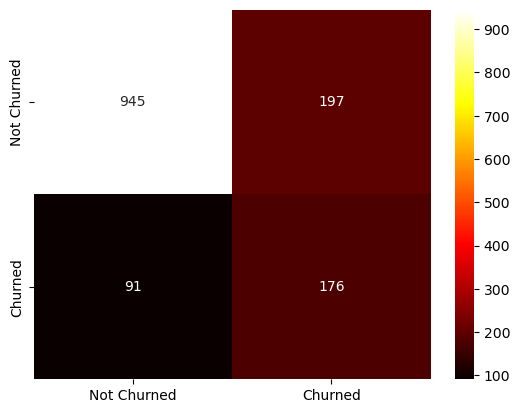

In [134]:
print("Accuracy: ", accuracy_score(y_pred, y_test))
print("\nClassification: ", classification_report(y_pred, y_test), '\n')

cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='hot', annot=True, fmt='d',
            xticklabels=['Not Churned', 'Churned'],   # TN  FP
            yticklabels=['Not Churned', 'Churned'])   # FN  TP
plt.show()

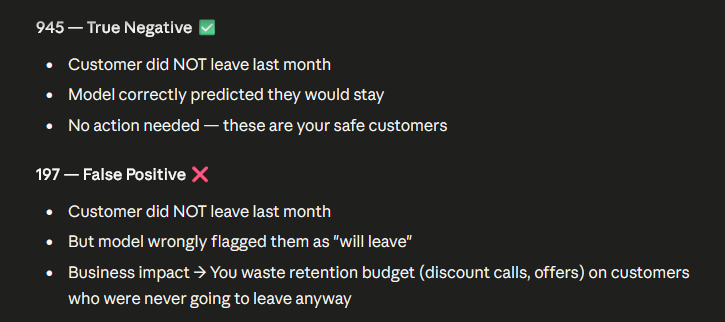
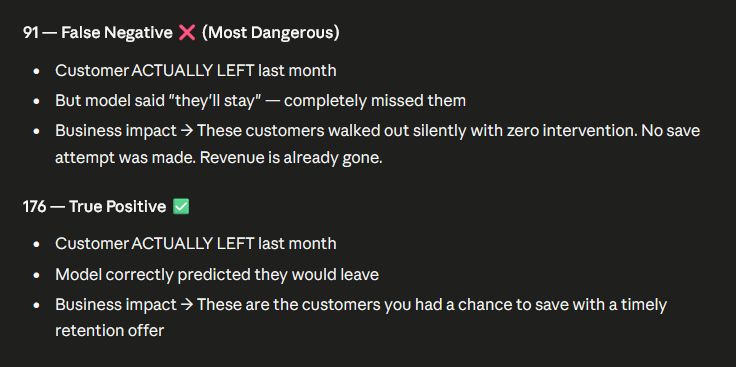